# R08 - Resource Semantics

> **Dados legados.** Este notebook analisa campanhas congeladas, geradas
> com o modelo escalar de fidelidade (`ket_vector`) antes da revisão de
> realismo físico (`docs/physical_model.md`). Os números valem como
> registro do manuscrito V1, não para o modelo físico atual; os resultados
> que o manuscrito V2 usa estão em `results/realistic/`
> (`docs/realistic_results.md`).

## Objetivo
Demonstrar que `reserved_memory_slots` (dimensiona o pool) e
`duration_s` (controla quantas vezes o pool pode ser reutilizado) são
dimensões ortogonais de controle, com dados reais da campanha final
`F08_resource_semantics` (three_node, 2x2 fatorial x 20 seeds). Ver
`docs/intent_resource_semantics.md`. Não roda simulação - carrega
apenas dados persistidos.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ibqn.experiments.aggregation import aggregate_records
from ibqn.experiments.export import save_figure, save_table

# Executed with cwd=notebooks/ regardless of this file's own subdirectory
# (tests/notebooks/test_notebooks.py's NotebookClient.execute(cwd=...)) -
# matches notebooks/article/A0*.ipynb's own convention, not a path
# relative to notebooks/article/final/ itself.
RESULTS_DIR = Path("../results")

# A dedicated subdirectory, not results/figures/final/ directly: that
# directory's *.pdf/*.png are the curated, audited figure set
# (scripts/generate_final_figures.py + sources.json, checked by
# scripts/audit_final_results.py) - a notebook's own reproducibility
# export must not silently add uncatalogued files there.
FIGURES_OUT = RESULTS_DIR / "figures" / "final" / "from_notebooks"
TABLES_OUT = RESULTS_DIR / "tables" / "final"


## Carregar dados e verificar consistência

In [2]:
CAMPAIGN = "F08_resource_semantics"
trials_df = pd.read_csv(RESULTS_DIR / "raw" / CAMPAIGN / "trials.csv")
manifest = json.load(open(RESULTS_DIR / "manifests" / f"{CAMPAIGN}.json", encoding="utf-8"))

assert len(trials_df) == manifest["completed_trials"] == 80
assert sorted(trials_df["reserved_memory_slots"].unique()) == [2, 10]
assert sorted(trials_df["duration_s"].unique()) == [0.02, 0.05]
trials_df.head(3)

,campaign,trial_id,scenario,parameter_hash,seed,intent_id,routing_strategy,purification_policy,reconciliation_enabled,route,...,ep_success,es_attempts,es_success,violations,error_type,error_message,project_git_commit,sequence_git_commit,python_version,timestamp
0,F08_resource_semantics,F08_resource_semantics:three_node:533b26a51fb9...,three_node,533b26a51fb9857a,0,f08-resource-semantics,shortest_hop_count,automatic,False,a -> r -> b,...,0,0,0,delivered_pairs >= 30.0 (observed=4.0) -> FAIL,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:47:25.011139+00:00
1,F08_resource_semantics,F08_resource_semantics:three_node:533b26a51fb9...,three_node,533b26a51fb9857a,1,f08-resource-semantics,shortest_hop_count,automatic,False,a -> r -> b,...,0,0,0,delivered_pairs >= 30.0 (observed=3.0) -> FAIL,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:47:25.084679+00:00
2,F08_resource_semantics,F08_resource_semantics:three_node:533b26a51fb9...,three_node,533b26a51fb9857a,2,f08-resource-semantics,shortest_hop_count,automatic,False,a -> r -> b,...,0,0,0,delivered_pairs >= 30.0 (observed=3.0) -> FAIL,NaN,NaN,f4343c314e5de5e01ee6970aaa14b5974c1b49ea,1f2680a5b9065e708a7497adc53a95b108029b98,3.13.14,2026-07-13T16:47:25.179463+00:00


## Agregação fatorial (n, média, IC95%)

In [3]:
summary = aggregate_records(
    trials_df, group_by=["reserved_memory_slots", "duration_s"],
    metrics=["delivered_pairs", "delivery_ratio", "deliveries_per_reserved_slot"],
)
save_table(summary, "R08_summary", directory=TABLES_OUT)
summary[["reserved_memory_slots", "duration_s", "metric", "n_valid", "mean", "ci95_low", "ci95_high"]]

,reserved_memory_slots,duration_s,metric,n_valid,mean,ci95_low,ci95_high
0,2,0.02,delivered_pairs,20,2.550000,1.952672,3.147328
1,2,0.02,delivery_ratio,20,0.085000,0.065089,0.104911
2,2,0.02,deliveries_per_reserved_slot,20,1.275000,0.976336,1.573664
3,2,0.05,delivered_pairs,20,5.950000,4.937359,6.962641
4,2,0.05,delivery_ratio,20,0.198333,0.164579,0.232088
5,2,0.05,deliveries_per_reserved_slot,20,2.975000,2.468680,3.481320
6,10,0.02,delivered_pairs,20,12.650000,11.521084,13.778916
7,10,0.02,delivery_ratio,20,0.421667,0.384036,0.459297
8,10,0.02,deliveries_per_reserved_slot,20,1.265000,1.152108,1.377892
9,10,0.05,delivered_pairs,20,35.100000,33.097617,37.102383


## Comparações estatísticas pareadas

In [4]:
stats_df = pd.read_csv(RESULTS_DIR / "processed" / CAMPAIGN / "statistical_comparisons.csv")
significant = stats_df[stats_df["p_value_holm_adjusted"] < 0.05]
print(f"{len(significant)}/{len(stats_df)} comparisons significant after Holm correction")
significant[["held_fixed", "varying_factor", "value_col", "n", "mean_a", "mean_b", "test_used", "p_value_holm_adjusted", "effect_size"]]

12/16 comparisons significant after Holm correction


,held_fixed,varying_factor,value_col,n,mean_a,mean_b,test_used,p_value_holm_adjusted,effect_size
0,duration_s=0.02,reserved_memory_slots,delivered_pairs,20,2.550000,12.650000,paired_t,4.363760e-12,3.398617
1,duration_s=0.02,reserved_memory_slots,delivery_ratio,20,0.085000,0.421667,paired_t,4.363760e-12,3.398617
4,duration_s=0.05,reserved_memory_slots,delivered_pairs,20,5.950000,35.100000,paired_t,9.902207e-16,5.405422
5,duration_s=0.05,reserved_memory_slots,delivery_ratio,20,0.198333,1.170000,paired_t,9.902207e-16,5.405422
7,duration_s=0.05,reserved_memory_slots,satisfied_num,20,0.000000,0.900000,wilcoxon,2.209050e-05,1.000000
8,reserved_memory_slots=2,duration_s,delivered_pairs,20,2.550000,5.950000,wilcoxon,7.413271e-05,1.000000
9,reserved_memory_slots=2,duration_s,delivery_ratio,20,0.085000,0.198333,wilcoxon,7.579016e-05,1.000000
10,reserved_memory_slots=2,duration_s,deliveries_per_reserved_slot,20,1.275000,2.975000,wilcoxon,7.413271e-05,1.000000
12,reserved_memory_slots=10,duration_s,delivered_pairs,20,12.650000,35.100000,paired_t,1.987233e-17,6.674587
13,reserved_memory_slots=10,duration_s,delivery_ratio,20,0.421667,1.170000,paired_t,1.987233e-17,6.674587


## Figura

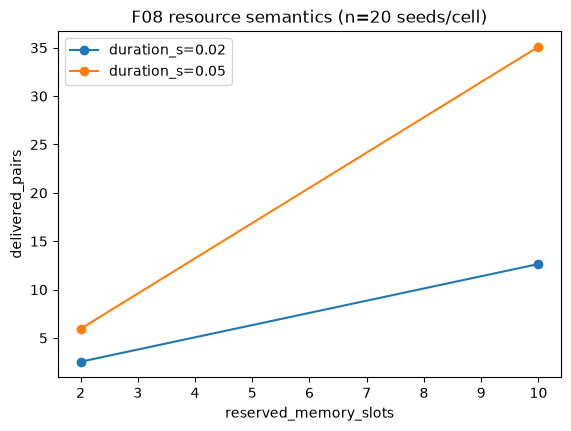

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for duration in sorted(trials_df["duration_s"].unique()):
    sub = trials_df[trials_df["duration_s"] == duration]
    means = sub.groupby("reserved_memory_slots")["delivered_pairs"].mean()
    ax.plot(means.index, means.values, "o-", label=f"duration_s={duration}")
ax.set_xlabel("reserved_memory_slots")
ax.set_ylabel("delivered_pairs")
ax.set_title(f"F08 resource semantics (n={trials_df['seed'].nunique()} seeds/cell)")
ax.legend()
save_figure(fig, "R08_delivered_pairs", directory=FIGURES_OUT)
plt.show()

## Conclusão

Ambos os fatores têm efeito independente e estatisticamente
significativo - `reserved_memory_slots` dimensiona o pool,
`duration_s` controla a reutilização; `delivery_ratio > 1` (entrega
excede a meta) é over-delivery, não duplicação ou erro
(`docs/intent_resource_semantics.md`).

## Limitações

Só uma topologia (`three_node`) e 2 níveis por fator - a ortogonalidade confirmada aqui não foi testada em topologias maiores ou com mais níveis.